# Size-mass relation — AIDA-TNG

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
from pathlib import Path
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors
import colorsys

AIDA_BASE = Path("/leonardo_work/CNHPC_1478837/AIDA/L35n1080")
NB_DIR = Path("/leonardo/home/userexternal/acosta01/master_thesis_project/notebooks/AIDA-TNG")
FIG_DIR = NB_DIR / "figures"

RUNS = {
    "CDM": AIDA_BASE / "L35n1080_CDM",
    "SIDM1": AIDA_BASE / "L35n1080_SIDM1",
    "vSIDM": AIDA_BASE / "L35n1080_vSIDM_correa",
}

h = 0.6774

SNAP_Z = {50: 1.0, 33: 2.0, 25: 3.0, 17: 5.0}
MODELS = ["CDM", "SIDM1", "vSIDM"]
MODEL_COLORS = {"CDM": "black", "SIDM1": "tab:blue", "vSIDM": "tab:orange"}

In [2]:
# Load stellar mass and half-mass radius of central subhalos per redshift per model
sm_data = {}

for snap, z in SNAP_Z.items():
    for model in MODELS:
        basePath = str(RUNS[model] / "output")

        cat = il.groupcat.loadHalos(basePath, snap, fields=["GroupFirstSub", "GroupFirstSub"])
        sub_mass = il.groupcat.loadSubhalos(basePath, snap, fields=["SubhaloMassType", "SubhaloHalfmassRadType"])

        first_sub = cat["GroupFirstSub"]
        valid = (first_sub >= 0) & (first_sub < len(sub_mass["SubhaloMassType"]))
        idx = first_sub[valid]

        mstar = sub_mass["SubhaloMassType"][idx, 4] * 1e10 / h  # Msun
        rhalf = sub_mass["SubhaloHalfmassRadType"][idx, 4] / h  # kpc

        # Keep galaxies with M* > 1e8 and R_half > 0
        sel = (mstar > 1e8) & (rhalf > 0)
        sm_data[(model, snap)] = {
            "mstar": mstar[sel],
            "rhalf": rhalf[sel],
        }
        print(f"{model} z={z:.0f} (snap {snap}): {sel.sum()} galaxies")

CDM z=1 (snap 50): 3514 galaxies
SIDM1 z=1 (snap 50): 3791 galaxies
vSIDM z=1 (snap 50): 3509 galaxies
CDM z=2 (snap 33): 3534 galaxies
SIDM1 z=2 (snap 33): 3846 galaxies
vSIDM z=2 (snap 33): 3538 galaxies
CDM z=3 (snap 25): 2767 galaxies
SIDM1 z=3 (snap 25): 2998 galaxies
vSIDM z=3 (snap 25): 2795 galaxies
CDM z=5 (snap 17): 889 galaxies
SIDM1 z=5 (snap 17): 972 galaxies
vSIDM z=5 (snap 17): 894 galaxies


In [ ]:
def lighten(color, amount=0.6):                   
      """Increase lightness in HLS space. amount=0 →
   original, amount=1 → white."""                   
      r, g, b = mcolors.to_rgb(color)             
      h_, l, s = colorsys.rgb_to_hls(r, g, b)       
      l_new = l + (1 - l) * amount
      return colorsys.hls_to_rgb(h_, l_new, s)

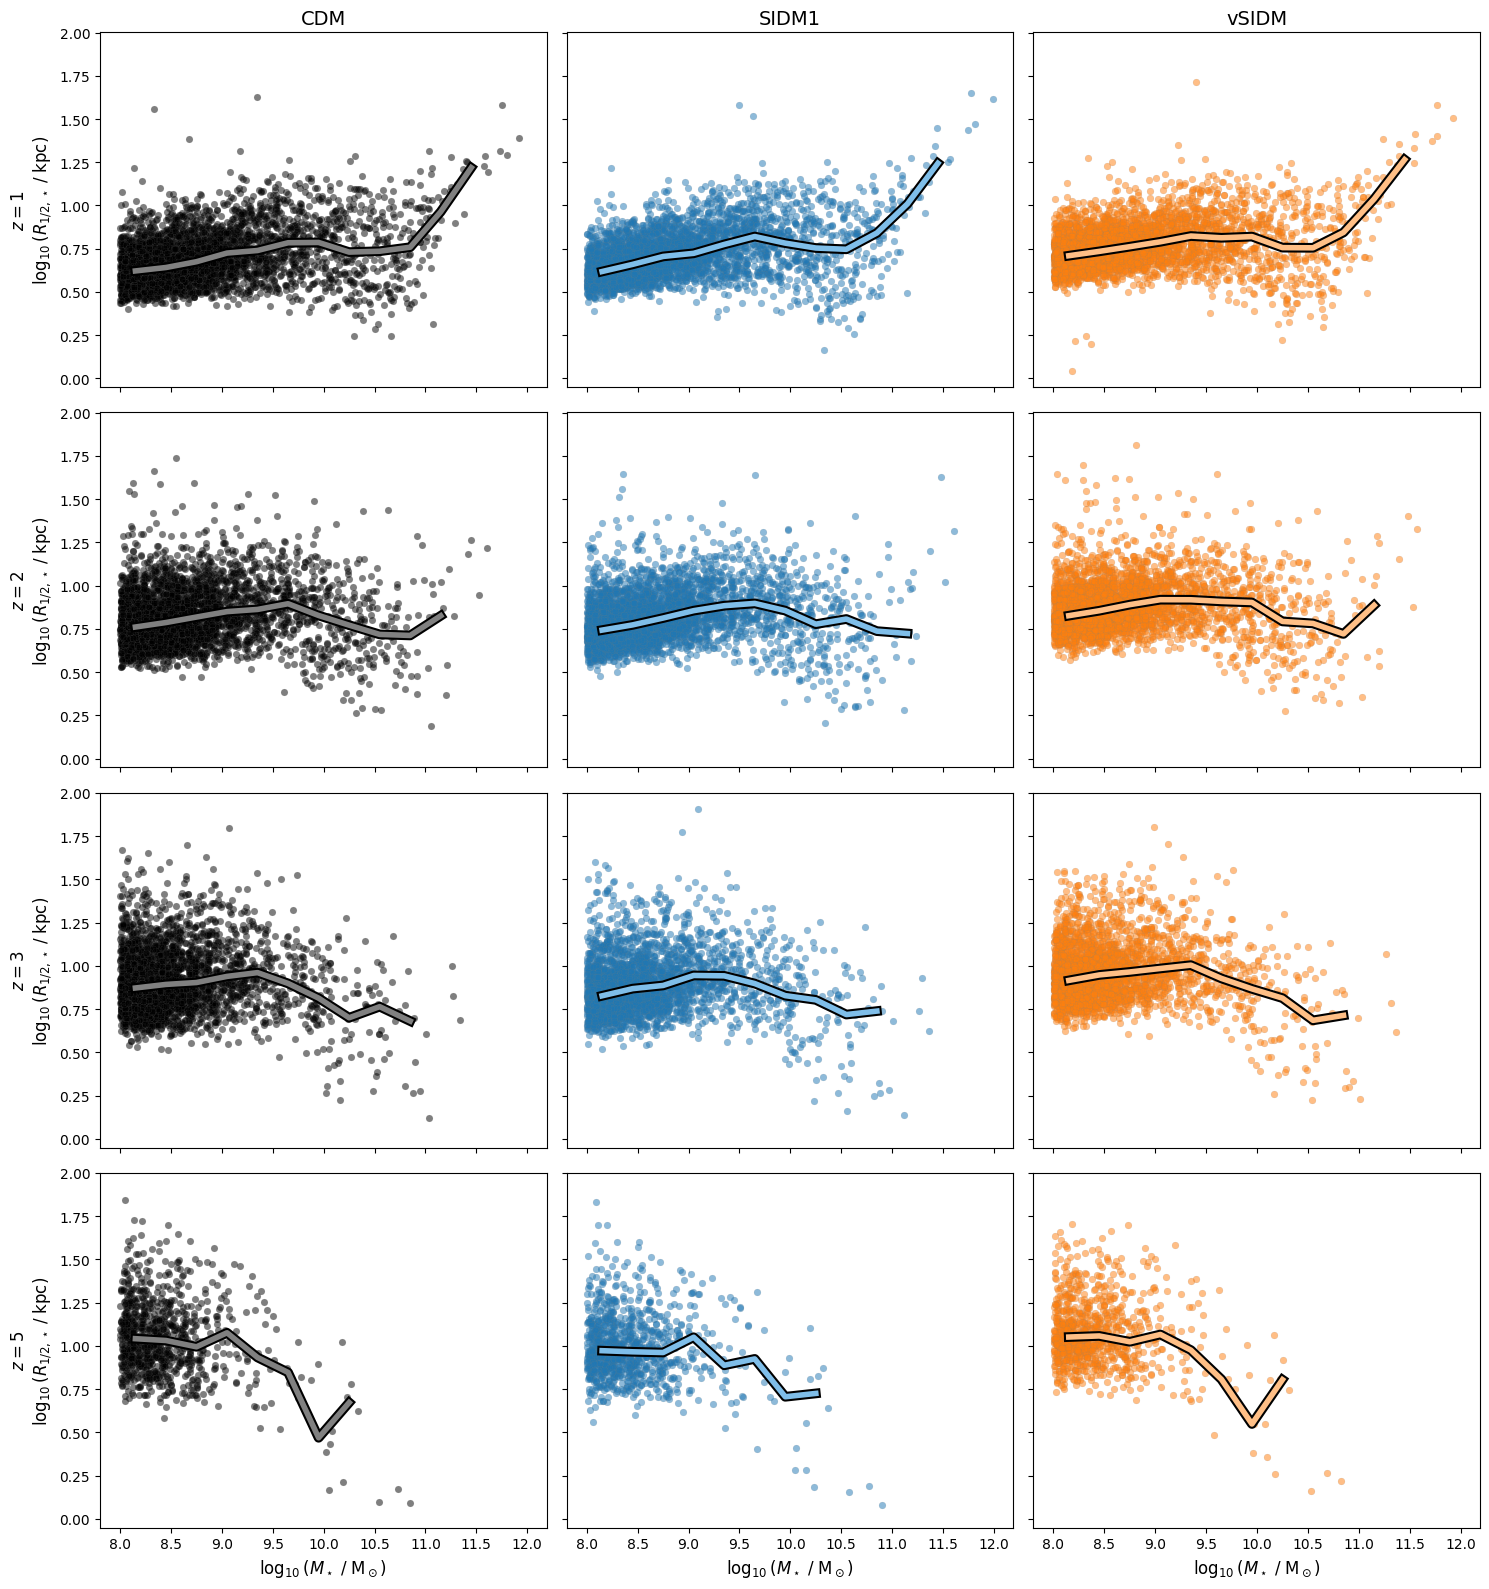

In [4]:
snaps = list(SNAP_Z.keys())
fig, axes = plt.subplots(len(snaps), len(MODELS),
                         figsize=(5 * len(MODELS), 4 * len(snaps)),
                         sharex=True, sharey=True)

mbins = np.arange(8.0, 12.1, 0.3)
mbin_centres = 0.5 * (mbins[:-1] + mbins[1:])

for row, snap in enumerate(snaps):
    z = SNAP_Z[snap]
    for col, model in enumerate(MODELS):
        ax = axes[row, col]
        data = sm_data[(model, snap)]
        log_m = np.log10(data["mstar"])
        log_r = np.log10(data["rhalf"])
        color = MODEL_COLORS[model]

        ax.scatter(log_m, log_r, s=25, alpha=0.5, color=color, edgecolors="grey", linewidths=0.15)

        medians = []
        centres = []
        for j in range(len(mbins) - 1):
            in_bin = (log_m >= mbins[j]) & (log_m < mbins[j + 1])
            if in_bin.sum() >= 5:
                medians.append(np.median(log_r[in_bin]))
                centres.append(mbin_centres[j])
        if medians:
            ax.plot(centres, medians, "-", color=lighten(color, 0.5), lw=4, path_effects=[pe.Stroke(linewidth=7, foreground="black"), pe.Normal()])

        if row == 0:
            ax.set_title(model, fontsize=14)
        if col == 0:
            ax.set_ylabel(rf"$z = {z:.0f}$" + "\n" + r"$\log_{10}(R_{1/2,\star}\;/\;\mathrm{kpc})$", fontsize=12)
        if row == len(snaps) - 1:
            ax.set_xlabel(r"$\log_{10}(M_\star\;/\;\mathrm{M_\odot})$", fontsize=12)

plt.tight_layout()
plt.savefig(FIG_DIR / "size_mass_mosaic.pdf", dpi=150, bbox_inches="tight")
plt.show()

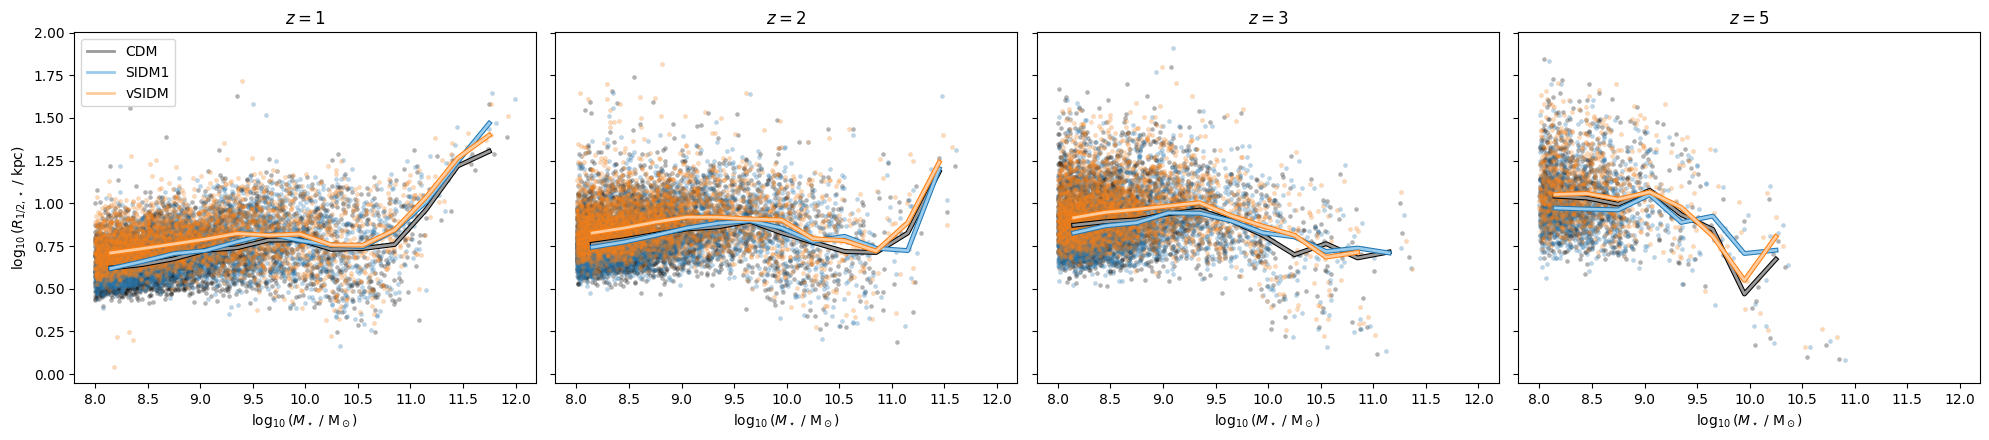

In [9]:
snaps = list(SNAP_Z.keys())
fig, axes = plt.subplots(1, len(snaps), figsize=(5 * len(snaps), 4.5),
                         sharex=True, sharey=True)

mbins = np.arange(8.0, 12.1, 0.3)
mbin_centres = 0.5 * (mbins[:-1] + mbins[1:])

for col, snap in enumerate(snaps):
    z = SNAP_Z[snap]
    ax = axes[col]
    for model in MODELS:
        data = sm_data[(model, snap)]
        log_m = np.log10(data["mstar"])
        log_r = np.log10(data["rhalf"])
        color = MODEL_COLORS[model]

        ax.scatter(log_m, log_r, s=10, alpha=0.3, color=color, edgecolors="grey", linewidths=0.15)

        medians, centres = [], []
        for j in range(len(mbins) - 1):
            in_bin = (log_m >= mbins[j]) & (log_m < mbins[j + 1])
            if in_bin.sum() >= 3:
                medians.append(np.median(log_r[in_bin]))
                centres.append(mbin_centres[j])
        if medians:
            ax.plot(centres, medians, "-", color=color, lw=3.5)
            ax.plot(centres, medians, "-", color=lighten(color, 0.6), lw=2, label=model)

    ax.set_title(rf"$z = {z:.0f}$")
    ax.set_xlabel(r"$\log_{10}(M_\star\;/\;\mathrm{M_\odot})$")
    if col == 0:
        ax.set_ylabel(r"$\log_{10}(R_{1/2,\star}\;/\;\mathrm{kpc})$")
        ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "size_mass_overlaid.pdf", dpi=150, bbox_inches="tight")
plt.show()
